100%|██████████| 1000/1000 [00:16<00:00, 60.25it/s]


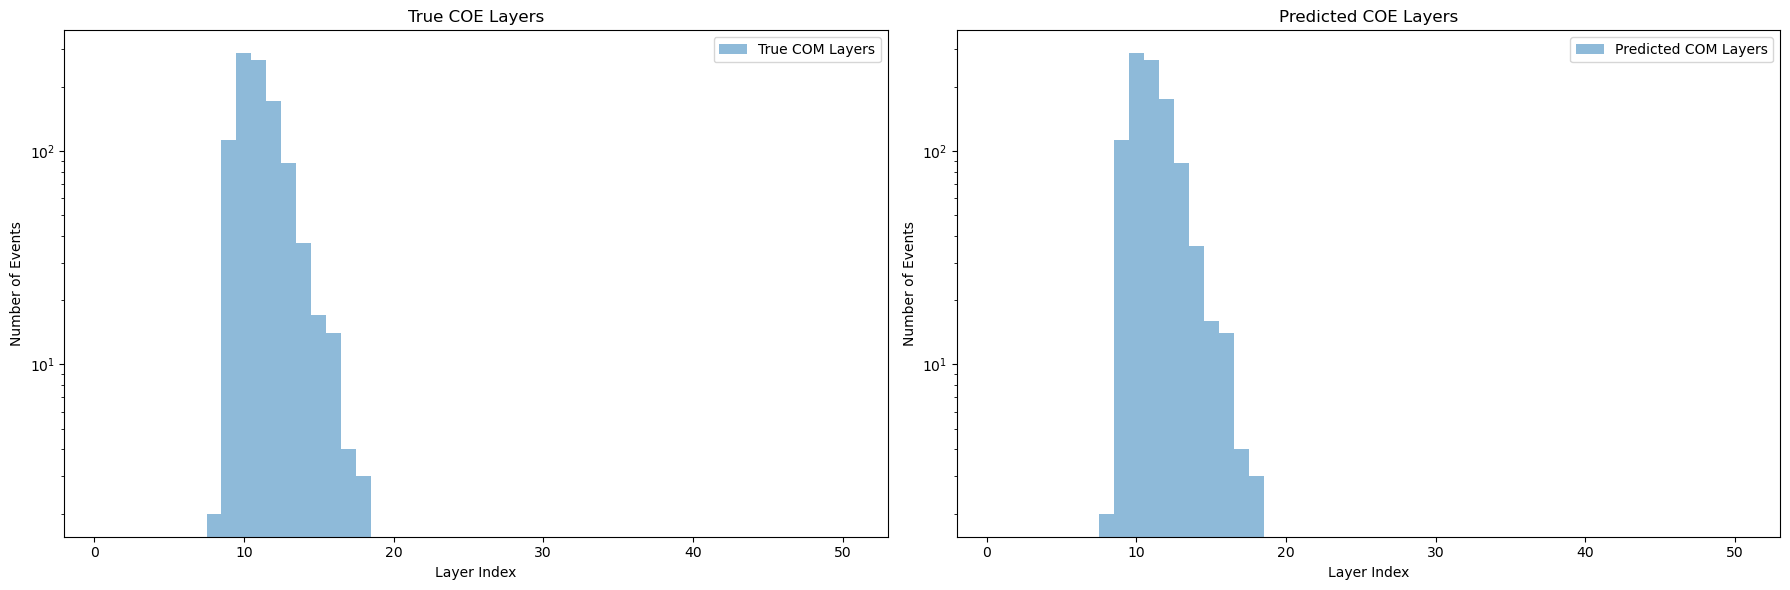

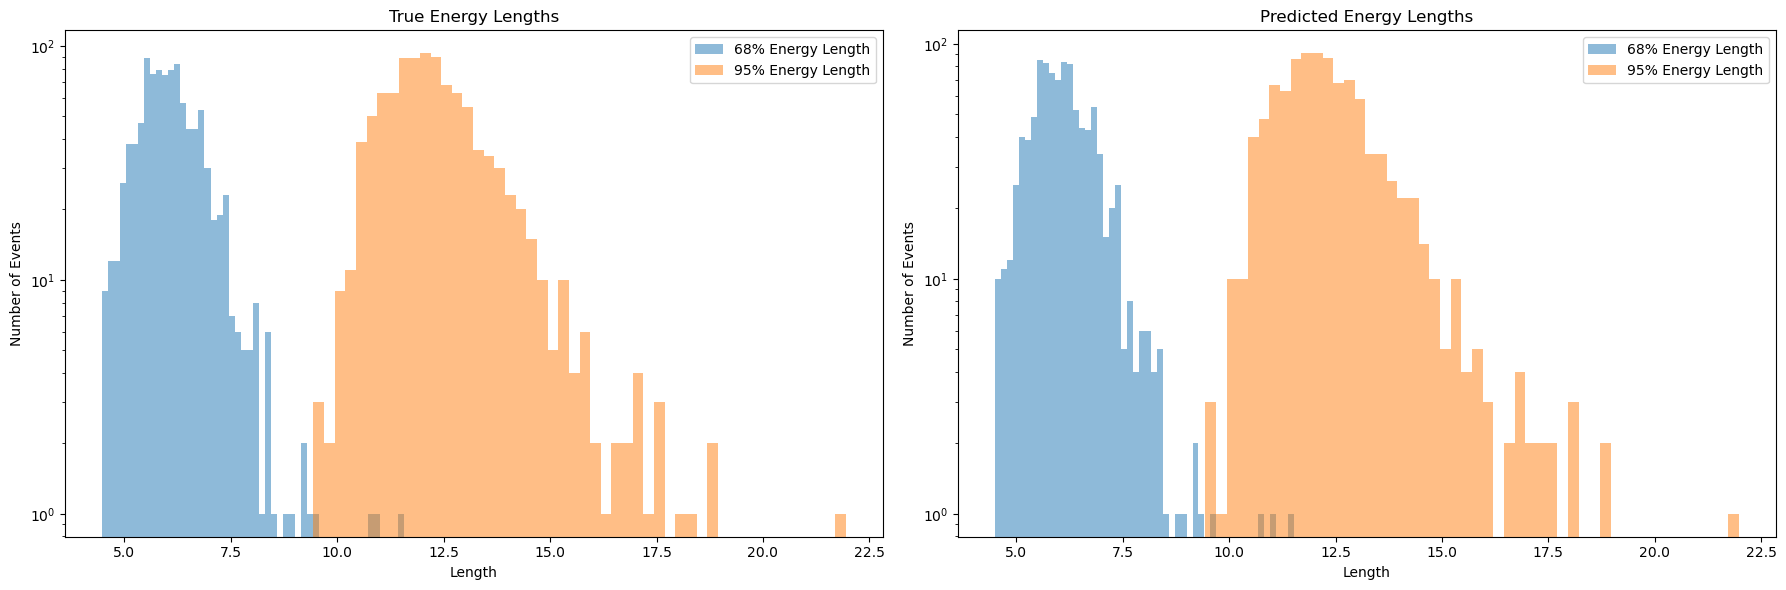

In [10]:
# Event Length: Center of energy followed by 68% and 95% energy radii

import pickle
import numpy as np
import torch
import glob
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set file pattern and file limit
file_pattern = r'C:\Users\tsoli\OneDrive\Documents\School\1 - University of Minnesota\Year 17\Year 1 Research\picklefiles\photons\*.pkl'
file_limit = 1000

# Layer positions for binning
layer_positions = [
    3.22e+02, 3.23e+02, 3.25e+02, 3.26e+02, 3.28e+02, 3.29e+02, 3.31e+02, 3.32e+02, 3.34e+02, 3.35e+02,
    3.37e+02, 3.38e+02, 3.40e+02, 3.41e+02, 3.43e+02, 3.44e+02, 3.46e+02, 3.47e+02, 3.49e+02, 3.50e+02,
    3.52e+02, 3.53e+02, 3.55e+02, 3.56e+02, 3.58e+02, 3.59e+02, 3.61e+02, 3.62e+02, 3.68e+02, 3.73e+02,
    3.79e+02, 3.84e+02, 3.89e+02, 3.95e+02, 4.00e+02, 4.06e+02, 4.11e+02, 4.17e+02, 4.22e+02, 4.28e+02,
    4.36e+02, 4.45e+02, 4.53e+02, 4.62e+02, 4.70e+02, 4.79e+02, 4.87e+02, 4.96e+02, 5.05e+02, 5.13e+02
]
layer_positions = np.array([int(pos) for pos in layer_positions])

# Load data from pkl files
def load_data(file_path):
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
        score_noise_filter = pickle.load(f)
        pass_noise_filter = pickle.load(f)
        out_gravnet = pickle.load(f)
    return data, score_noise_filter, pass_noise_filter, out_gravnet

# Clustering algorithm from plots3D.
def get_clustering(beta, X, threshold_beta=0.2, threshold_dist=0.5):
    n_points = beta.shape[0]
    select_condpoints = beta > threshold_beta
    indices_condpoints = np.nonzero(select_condpoints)[0]
    indices_condpoints = indices_condpoints[np.argsort(-beta[select_condpoints])]
    unassigned = np.arange(n_points)
    clustering = -1 * np.ones(n_points, dtype=np.int32)
    
    for index_condpoint in indices_condpoints:
        d = np.linalg.norm(X[unassigned] - X[index_condpoint], axis=-1)
        assigned_to_this_condpoint = unassigned[d < threshold_dist]
        clustering[assigned_to_this_condpoint] = index_condpoint
        unassigned = unassigned[~(d < threshold_dist)]
    
    return clustering

# Parsing true input.
def process_data(data):
    true_energies = data.x[:, 0].numpy()
    true_clusters = data.y.numpy()
    xpos = data.x[:, 5].numpy()
    ypos = data.x[:, 6].numpy()
    zpos = data.x[:, 7].numpy()
    return true_energies, true_clusters, xpos, ypos, zpos

# Parsing network output.
def process_gravnet(score_noise_filter, pass_noise_filter, out_gravnet):
    beta = torch.sigmoid(out_gravnet[:, 0]).numpy()
    cluster_space_coords = out_gravnet[:, 1:].numpy()
    pred_clusters_pnf = get_clustering(beta, cluster_space_coords, threshold_beta=0.2, threshold_dist=0.5)
    pred_clusters = np.zeros_like(pass_noise_filter, dtype=np.int32)
    pred_clusters[pass_noise_filter] = pred_clusters_pnf
    
    # Count hits per cluster
    unique, counts = np.unique(pred_clusters, return_counts=True)
    cluster_counts = dict(zip(unique, counts))
    
    # Create final_pred_hits with clusters having less than 100 hits labeled as -2
    final_pred_hits = np.array([cluster if cluster_counts[cluster] >= 100 else -2 for cluster in pred_clusters])
    
    return final_pred_hits

def find_nearest_layer(zpos, layer_positions):
    nearest_layers = np.array([layer_positions[np.argmin(np.abs(layer_positions - z))] for z in zpos])
    return nearest_layers

def calculate_com_and_radii(cluster_indices, xpos, ypos, zpos, energies):
    z_com = np.sum(zpos[cluster_indices] * energies[cluster_indices]) / np.sum(energies[cluster_indices])
    nearest_layer_com = layer_positions[np.argmin(np.abs(layer_positions - z_com))]
    
    distances = np.abs(zpos[cluster_indices] - z_com)
    sorted_indices = np.argsort(distances)
    sorted_energies = energies[cluster_indices][sorted_indices]
    cumulative_energies = np.cumsum(sorted_energies)
    total_energy = cumulative_energies[-1]
    
    length_68 = distances[sorted_indices][np.searchsorted(cumulative_energies, 0.68 * total_energy)]
    length_95 = distances[sorted_indices][np.searchsorted(cumulative_energies, 0.95 * total_energy)]
    
    return nearest_layer_com, length_68, length_95

def main():
    files = glob.glob(file_pattern)[:file_limit]

    com_layers_pred = []
    com_layers_true = []
    length_68_pred = []
    length_95_pred = []
    length_68_true = []
    length_95_true = []

    for file_path in tqdm(files):
        data, score_noise_filter, pass_noise_filter, out_gravnet = load_data(file_path)
        true_energies, true_clusters, xpos, ypos, zpos = process_data(data)
        final_pred_hits = process_gravnet(score_noise_filter, pass_noise_filter, out_gravnet)
        
        # Filter out noise hits for predicted clusters
        valid_pred_indices = np.where((final_pred_hits != -1) & (final_pred_hits != 0) & (final_pred_hits != -2))[0]
        event_energies_pred = true_energies[valid_pred_indices]
        event_xpos_pred = xpos[valid_pred_indices]
        event_ypos_pred = ypos[valid_pred_indices]
        event_zpos_pred = zpos[valid_pred_indices]
        
        # Filter out noise hits for true clusters
        valid_true_indices = np.where(true_clusters != 0)[0]
        event_energies_true = true_energies[valid_true_indices]
        event_xpos_true = xpos[valid_true_indices]
        event_ypos_true = ypos[valid_true_indices]
        event_zpos_true = zpos[valid_true_indices]

        # Calculate COE and lengths for the entire event
        if len(event_energies_pred) > 0:
            com_layer_pred, length_68_pred_event, length_95_pred_event = calculate_com_and_radii(
                np.arange(len(event_energies_pred)), event_xpos_pred, event_ypos_pred, event_zpos_pred, event_energies_pred)
            com_layers_pred.append(com_layer_pred)
            length_68_pred.append(length_68_pred_event)
            length_95_pred.append(length_95_pred_event)

        if len(event_energies_true) > 0:
            com_layer_true, length_68_true_event, length_95_true_event = calculate_com_and_radii(
                np.arange(len(event_energies_true)), event_xpos_true, event_ypos_true, event_zpos_true, event_energies_true)
            com_layers_true.append(com_layer_true)
            length_68_true.append(length_68_true_event)
            length_95_true.append(length_95_true_event)
        
    # Convert COE layers to layer indices
    com_layer_indices_pred = [np.argmin(np.abs(layer_positions - com)) + 1 for com in com_layers_pred]
    com_layer_indices_true = [np.argmin(np.abs(layer_positions - com)) + 1 for com in com_layers_true]

    # Plot histograms for COE layer indices
    plt.figure(figsize=(18, 6))
    
    # Plot histogram for true COE layers
    plt.subplot(1, 2, 1)
    plt.hist(com_layer_indices_true, bins=np.arange(1, len(layer_positions) + 2) - 0.5, alpha=0.5, label='True COM Layers')
    plt.xlabel('Layer Index')
    plt.ylabel('Number of Events')
    plt.title('True COE Layers')
    plt.legend()
    plt.yscale('log')
    
    # Plot histogram for predicted COE layers
    plt.subplot(1, 2, 2)
    plt.hist(com_layer_indices_pred, bins=np.arange(1, len(layer_positions) + 2) - 0.5, alpha=0.5, label='Predicted COM Layers')
    plt.xlabel('Layer Index')
    plt.ylabel('Number of Events')
    plt.title('Predicted COE Layers')
    plt.legend()
    plt.yscale('log')
    
    plt.tight_layout()
    plt.show()

    # Plot histograms for lengths enclosing 68% and 95% of the total energy
    plt.figure(figsize=(18, 6))
    
    # Plot histogram for true lengths
    plt.subplot(1, 2, 1)
    plt.hist(length_68_true, bins=50, alpha=0.5, label='68% Energy Length')
    plt.hist(length_95_true, bins=50, alpha=0.5, label='95% Energy Length')
    plt.xlabel('Length')
    plt.ylabel('Number of Events')
    plt.title('True Energy Lengths')
    plt.legend()
    plt.yscale('log')
    
    # Plot histogram for predicted lengths
    plt.subplot(1, 2, 2)
    plt.hist(length_68_pred, bins=50, alpha=0.5, label='68% Energy Length')
    plt.hist(length_95_pred, bins=50, alpha=0.5, label='95% Energy Length')
    plt.xlabel('Length')
    plt.ylabel('Number of Events')
    plt.title('Predicted Energy Lengths')
    plt.legend()
    plt.yscale('log')
    
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()

100%|██████████| 1000/1000 [00:16<00:00, 59.47it/s]


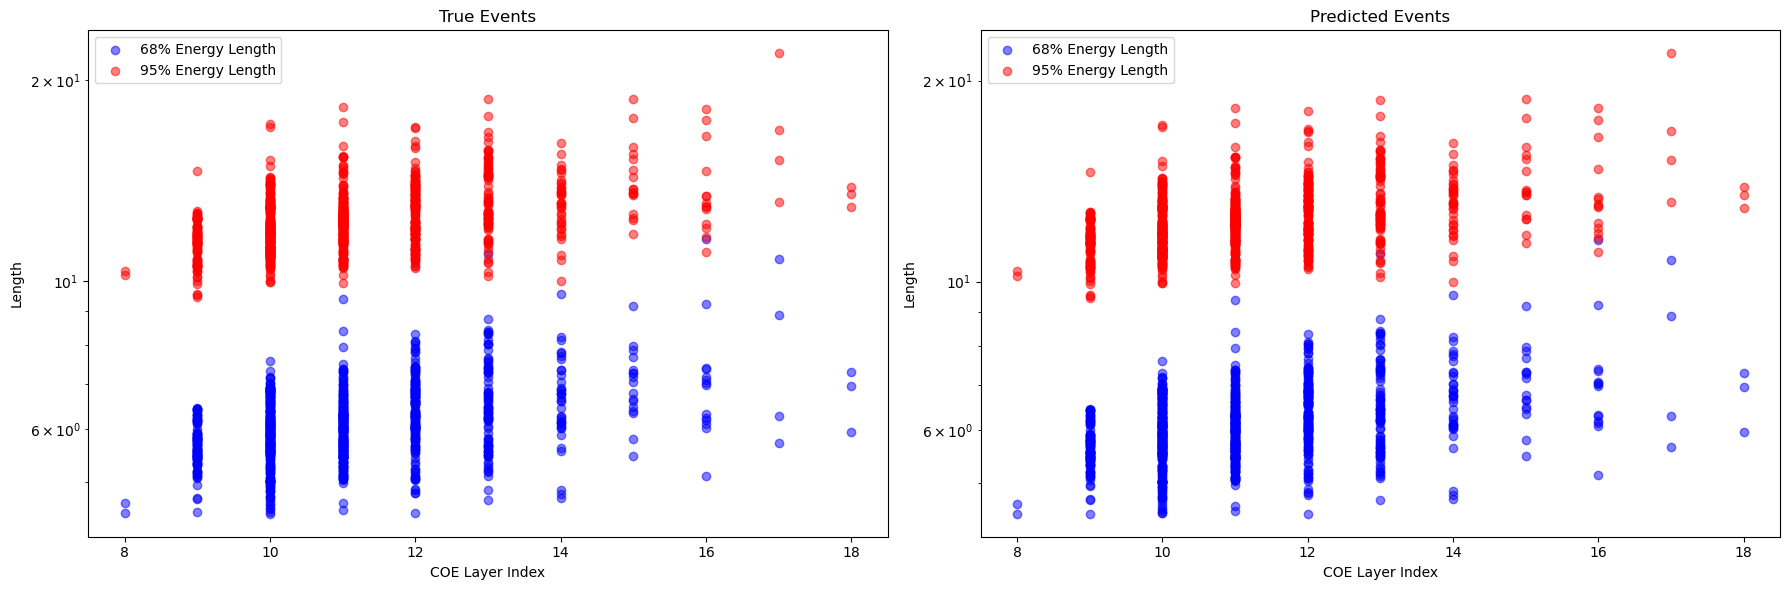

In [9]:
# Event Length: Center of energy followed by 68% and 95% energy radii

import pickle
import numpy as np
import torch
import glob
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set file pattern and file limit
file_pattern = r'C:\Users\tsoli\OneDrive\Documents\School\1 - University of Minnesota\Year 17\Year 1 Research\picklefiles\photons\*.pkl'
file_limit = 1000

# Layer positions for binning
layer_positions = [
    3.22e+02, 3.23e+02, 3.25e+02, 3.26e+02, 3.28e+02, 3.29e+02, 3.31e+02, 3.32e+02, 3.34e+02, 3.35e+02,
    3.37e+02, 3.38e+02, 3.40e+02, 3.41e+02, 3.43e+02, 3.44e+02, 3.46e+02, 3.47e+02, 3.49e+02, 3.50e+02,
    3.52e+02, 3.53e+02, 3.55e+02, 3.56e+02, 3.58e+02, 3.59e+02, 3.61e+02, 3.62e+02, 3.68e+02, 3.73e+02,
    3.79e+02, 3.84e+02, 3.89e+02, 3.95e+02, 4.00e+02, 4.06e+02, 4.11e+02, 4.17e+02, 4.22e+02, 4.28e+02,
    4.36e+02, 4.45e+02, 4.53e+02, 4.62e+02, 4.70e+02, 4.79e+02, 4.87e+02, 4.96e+02, 5.05e+02, 5.13e+02
]
layer_positions = np.array([int(pos) for pos in layer_positions])

# Load data from pkl files
def load_data(file_path):
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
        score_noise_filter = pickle.load(f)
        pass_noise_filter = pickle.load(f)
        out_gravnet = pickle.load(f)
    return data, score_noise_filter, pass_noise_filter, out_gravnet

# Clustering algorithm from plots3D.
def get_clustering(beta, X, threshold_beta=0.2, threshold_dist=0.5):
    n_points = beta.shape[0]
    select_condpoints = beta > threshold_beta
    indices_condpoints = np.nonzero(select_condpoints)[0]
    indices_condpoints = indices_condpoints[np.argsort(-beta[select_condpoints])]
    unassigned = np.arange(n_points)
    clustering = -1 * np.ones(n_points, dtype=np.int32)
    
    for index_condpoint in indices_condpoints:
        d = np.linalg.norm(X[unassigned] - X[index_condpoint], axis=-1)
        assigned_to_this_condpoint = unassigned[d < threshold_dist]
        clustering[assigned_to_this_condpoint] = index_condpoint
        unassigned = unassigned[~(d < threshold_dist)]
    
    return clustering

# Parsing true input.
def process_data(data):
    true_energies = data.x[:, 0].numpy()
    true_clusters = data.y.numpy()
    xpos = data.x[:, 5].numpy()
    ypos = data.x[:, 6].numpy()
    zpos = data.x[:, 7].numpy()
    return true_energies, true_clusters, xpos, ypos, zpos

# Parsing network output.
def process_gravnet(score_noise_filter, pass_noise_filter, out_gravnet):
    beta = torch.sigmoid(out_gravnet[:, 0]).numpy()
    cluster_space_coords = out_gravnet[:, 1:].numpy()
    pred_clusters_pnf = get_clustering(beta, cluster_space_coords, threshold_beta=0.2, threshold_dist=0.5)
    pred_clusters = np.zeros_like(pass_noise_filter, dtype=np.int32)
    pred_clusters[pass_noise_filter] = pred_clusters_pnf
    
    # Count hits per cluster
    unique, counts = np.unique(pred_clusters, return_counts=True)
    cluster_counts = dict(zip(unique, counts))
    
    # Create final_pred_hits with clusters having less than 100 hits labeled as -2
    final_pred_hits = np.array([cluster if cluster_counts[cluster] >= 100 else -2 for cluster in pred_clusters])
    
    return final_pred_hits

def find_nearest_layer(zpos, layer_positions):
    nearest_layers = np.array([layer_positions[np.argmin(np.abs(layer_positions - z))] for z in zpos])
    return nearest_layers

def calculate_com_and_radii(cluster_indices, xpos, ypos, zpos, energies):
    z_com = np.sum(zpos[cluster_indices] * energies[cluster_indices]) / np.sum(energies[cluster_indices])
    nearest_layer_com = layer_positions[np.argmin(np.abs(layer_positions - z_com))]
    
    distances = np.abs(zpos[cluster_indices] - z_com)
    sorted_indices = np.argsort(distances)
    sorted_energies = energies[cluster_indices][sorted_indices]
    cumulative_energies = np.cumsum(sorted_energies)
    total_energy = cumulative_energies[-1]
    
    length_68 = distances[sorted_indices][np.searchsorted(cumulative_energies, 0.68 * total_energy)]
    length_95 = distances[sorted_indices][np.searchsorted(cumulative_energies, 0.95 * total_energy)]
    
    return nearest_layer_com, length_68, length_95

def main():
    files = glob.glob(file_pattern)[:file_limit]

    com_layers_pred = []
    com_layers_true = []
    length_68_pred = []
    length_95_pred = []
    length_68_true = []
    length_95_true = []

    for file_path in tqdm(files):
        data, score_noise_filter, pass_noise_filter, out_gravnet = load_data(file_path)
        true_energies, true_clusters, xpos, ypos, zpos = process_data(data)
        final_pred_hits = process_gravnet(score_noise_filter, pass_noise_filter, out_gravnet)
        
        # Filter out noise hits for predicted clusters
        valid_pred_indices = np.where((final_pred_hits != -1) & (final_pred_hits != 0) & (final_pred_hits != -2))[0]
        event_energies_pred = true_energies[valid_pred_indices]
        event_xpos_pred = xpos[valid_pred_indices]
        event_ypos_pred = ypos[valid_pred_indices]
        event_zpos_pred = zpos[valid_pred_indices]
        
        # Filter out noise hits for true clusters
        valid_true_indices = np.where(true_clusters != 0)[0]
        event_energies_true = true_energies[valid_true_indices]
        event_xpos_true = xpos[valid_true_indices]
        event_ypos_true = ypos[valid_true_indices]
        event_zpos_true = zpos[valid_true_indices]

        # Calculate COE and lengths for the entire event
        if len(event_energies_pred) > 0:
            com_layer_pred, length_68_pred_event, length_95_pred_event = calculate_com_and_radii(
                np.arange(len(event_energies_pred)), event_xpos_pred, event_ypos_pred, event_zpos_pred, event_energies_pred)
            com_layers_pred.append(com_layer_pred)
            length_68_pred.append(length_68_pred_event)
            length_95_pred.append(length_95_pred_event)

        if len(event_energies_true) > 0:
            com_layer_true, length_68_true_event, length_95_true_event = calculate_com_and_radii(
                np.arange(len(event_energies_true)), event_xpos_true, event_ypos_true, event_zpos_true, event_energies_true)
            com_layers_true.append(com_layer_true)
            length_68_true.append(length_68_true_event)
            length_95_true.append(length_95_true_event)
        
    # Convert COE layers to layer indices
    com_layer_indices_pred = [np.argmin(np.abs(layer_positions - com)) + 1 for com in com_layers_pred]
    com_layer_indices_true = [np.argmin(np.abs(layer_positions - com)) + 1 for com in com_layers_true]

    # Plot scatter plots for COE layer vs. 68% and 95% lengths
    plt.figure(figsize=(18, 6))
    
    # Scatter plot for true events
    plt.subplot(1, 2, 1)
    plt.scatter(com_layer_indices_true, length_68_true, alpha=0.5, label='68% Energy Length', color='blue')
    plt.scatter(com_layer_indices_true, length_95_true, alpha=0.5, label='95% Energy Length', color='red')
    plt.xlabel('COE Layer Index')
    plt.ylabel('Length')
    plt.title('True Events')
    plt.legend()
    plt.yscale('log')
    
    # Scatter plot for predicted events
    plt.subplot(1, 2, 2)
    plt.scatter(com_layer_indices_pred, length_68_pred, alpha=0.5, label='68% Energy Length', color='blue')
    plt.scatter(com_layer_indices_pred, length_95_pred, alpha=0.5, label='95% Energy Length', color='red')
    plt.xlabel('COE Layer Index')
    plt.ylabel('Length')
    plt.title('Predicted Events')
    plt.legend()
    plt.yscale('log')
    
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()